<a href="https://colab.research.google.com/github/eacasas/algoritmosOptimizacion/blob/main/EfraimCasas_TrabajoPr%C3%A1ctico_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Efraím Alberto Casas Herrera  <br>
Url: https://colab.research.google.com/drive/1oXz50K2Qg18VovnWeNPCkqgBAlZtGgYu?usp=sharing <br>

https://github.com/eacasas/algoritmosOptimizacion

https://github.com/eacasas/algoritmosOptimizacion/blob/main/EfraimCasas_TrabajoPr%C3%A1ctico_Algoritmos.ipynb

Problema:
>2. Organizar los horarios de partidos de La Liga<br>

Descripción del problema: Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de
liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un
algoritmo que realice la asignación de los partidos a los horarios de forma que maximice la
audiencia. 





                                        


**¿Cuantas posibilidades hay sin tener en cuenta las restricciones?**  


Si tenemos 10 partidos y 10 horarios posibles la cantidad de posibilidades sería 10! es decir 3,628,800 posibilidades. Si cada partido se juega en un horario diferente. Sin la resticciones. 

<br>

**¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones?**

Hay dos restrcciones importantes a tener en cuenta:
1. Se debe garantizar que dos (Viernes y Lunes) partidos siempre se jueguen. 
2. Es posible que varios partidos se jueguen en un mismo horario, teniendo en cuentas la restricción anterior. 

Para este casi habria que sacar la probabilidad e jugar 8 partidos en 8 horarios, con la posibilidad de que en un horario se puedan jugar varios partidos. 

(2^8)^8 = 429.4967.296
este resultado se multiplicaria por 2 que son las dos posibilidades de los partidos del viernes y domingo, los cuales tendrían dos opciones de jugarse. 







**Modelo para el espacio de soluciones**

<br>
(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


Respuesta : 


* **Matriz de Audiencia**: Se utilizó una matriz de audiencia, en la cual se obtiene la audiencia esperada (en millones) dependiendo de la categoría de los equipos enfrentados. A esta matriz la llamé: audienceMatrix.


* **Diccionario de ponderación de audiencia**: Se creó un diccionario en el que se establece la ponderación de la audiencia (factor por el que se multiplica) según el horario. Este diccoonario tiene el nombre: dicSchedulePon




* **Resultados final** (programación completa) La estructura de datos que se utilizó es un dataframe de pandas. para crear permutaciones y aleatoriedad, convertía partes del dataframe de pandas a listas nativas de Python. Se usó el Dataframe de pandas dado que existe un número de información de cada jornada que es relevante para el problema y que tiene formatos diferentes. El horario es un texto, las ponderaciones son float, el partido es una tupla. Por experiencia se consideró que un Dataframe era el que mejor iba a manejar la estructura de los datos, de forma más organizada.


**Según el modelo para el espacio de soluciones**
<br>
(*)¿Cual es la función objetivo?

(*)¿Es un problema de maximización o minimización?

Respuesta: 
Es tes un problema de máximización, la idea es poder maximizar el número de audiencia.

La función obejetivos es:

Sumatoria de: AudienciaBase * PonderaciónHorarios * (1-coincidencia)

Desde i has ta n: Siendo n la cantidad de encuentros de la jornada


**Diseña un algoritmo para resolver el problema por fuerza bruta**

Respuesta: Para diseñar un algoritmo de fuerzar bruta es necesario crear todas la combinaciones posibles entre horarios y juegos, para luego evaluar cada una las posibles soluciones y escoger la que mayor audiencia potencial brinde. 

* Pseudo-código:



```
iteraciones := GenerarIteraciones(partidos, horarios);
mejor_audiencia=0;
mejor_programacion=null;

para programacion en ieraciones:
  temp_audiencia = getAudiencia(programacion);
  
  si temp_audiencia > mejor_audiencia entonces:
    mejor_audiencia := temp_audiencia;    
    mejor_programacion := programacion;
  fin si
fin para

deolver mejor_programacion
```
Cómo veremos a continuación, es posible generar una buena solución con un pequeño -comparativamente- número de itelaciones. Por ese motivo no se implementará un algoritmo de fuerza bruta completa.

Calcula la complejidad del algoritmo por fuerza bruta



Respuesta 

La complejidad del algoritmo de fuerza bruta es: O(n!)

# Diseño de algoritmo Metaheurístico

A continuación se realizará la implementación de varias técnicas con el fin de llegar a una buena solución para el problema. En la técnicas que vamos a utilizar estarán: 


* Técnica voraz.
* Búsqueda Aleatoria.
* Búsqueda Local.
* Generador de partidos simultáneos.
* Simulated Annealing.


## 1. Carga de datos iniciales 

a). A continuación se va a realizar la carga de los equipos con sus respectivas categorias, para efectos de practicidad y agilidad se agregó una nueva columna llamada index_cat: Esta es un equivalentes entre la categoría y el número de indice, para luego dar agilidad en las busquedas de las audiencias. A=0; B=1; C=2.

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import random
import math

In [2]:
#Esta es una dataframe global que se utilizará para almacenar los resultados de las iteraciones y su audiencia
resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

In [3]:
#Se importa el csv, con los equipos y categorpias. Siguiendo las restricciones del problema. 
#3 equipos en la categoría A, 11 equipos de categoría B y 6 equipos de categoría C.
teamCategory=pd.read_csv('/content/sample_data/TeamCategory.csv')
teamCategory['category'] = teamCategory['category'].astype("string")
display(teamCategory)



,team,category,index_cat
0,Real Madrid,A,0
1,Barcelona,A,0
2,Atletico,A,0
3,Celta,B,1
4,Valencia,B,1
5,R. Sociedad,B,1
6,Athletic,B,1
7,Villareal,B,1
8,Alaves,B,1
9,Levante,B,1


Se definirá un diccionarío con la información de los horarios y su ponderación, esta contiene el horario en la columna schedule y su coeficiente en la columna coeff

In [4]:
#Se crea un diccionario con la información de los horarios
dicSchedulePon = { "schedule" : ["V20","S12","S16", "S18","S20","D12","D16", "D18","D20","L20"], 
                    "coeff" : [0.4,0.55,0.7, 0.8,1,0.45,0.75,0.85,1,0.4]}
schedulePon = pd.DataFrame(dicSchedulePon)

display(schedulePon)

,schedule,coeff
0,V20,0.40
1,S12,0.55
2,S16,0.70
3,S18,0.80
4,S20,1.00
5,D12,0.45
6,D16,0.75
7,D18,0.85
8,D20,1.00
9,L20,0.40


Se definirá la matriz de audiencia, según la condiciones dada. Con esta se podrá establecer la audiencia esperada cuando se enfrentan dos equipos.

In [5]:
audienceMatrix = [[2,   1.3,    1],
                  [1.3, 0.9,  0.75],
                  [1,   0.75, 0.47]]

## 2. Generador de partidos aleatorios

Para probar la efectividad el algoritmo vamos a realizar un artefacto generador de todos los partidos de una joranada, con su ponderación de audiencia según la matriz de audiencia.

In [160]:
#Se generan tuplas aleatorias 
def match_pairs(df):
    elements = df['team'].tolist()
    random.shuffle(elements)
    return list(zip(elements[::2], elements[1::2]))

In [161]:
result = match_pairs(teamCategory)
print(result)

[('Getafe', 'Valencia'), ('Leganes', 'Athletic'), ('Osasuna', 'Real Madrid'), ('Español', 'Barcelona'), ('Mallorca', 'Valladolid'), ('Granada', 'Celta'), ('Atletico', 'Betis'), ('Sevilla', 'Villareal'), ('Eibar', 'R. Sociedad'), ('Levante', 'Alaves')]




Ya tenemos una función capaz de generar todos los partidos de una jornada de forma aleatoria. Ahora completaremos la información de cada encuento con la categoría de los equipos y la base de audiencia.


In [163]:
def generate_maths(teamCategory):
  journey = pd.DataFrame(columns=['match','category','base_m'])
  result = match_pairs(teamCategory)
  for matchJ in result:
      #Se trae la información delos equipos
      teamInfo0 = teamCategory[teamCategory['team']==matchJ[0]]
      teamInfo1 = teamCategory[teamCategory['team']==matchJ[1]]
      #Se consultan las categorias
      category0, category1 = teamInfo0['category'].tolist()[0], teamInfo1['category'].tolist()[0]
      #Se consulta el indice
      index0, index1 = int(teamInfo0['index_cat']), int(teamInfo1['index_cat'])
      base = audienceMatrix[index0][index1]

      new_row = {'match':matchJ,'category': (category0, category1) ,'base_m':base}
      journey=journey.append(new_row,ignore_index=True)

  return journey

In [166]:
print(generate_maths(teamCategory))

                    match category  base_m
0       (Mallorca, Celta)   (C, B)    0.75
1    (Real Madrid, Betis)   (A, B)    1.30
2       (Granada, Getafe)   (C, B)    0.75
3     (Valencia, Leganes)   (B, C)    0.75
4      (Villareal, Eibar)   (B, C)    0.75
5  (R. Sociedad, Levante)   (B, B)    0.90
6   (Valladolid, Español)   (C, B)    0.75
7     (Osasuna, Athletic)   (C, B)    0.75
8   (Atletico, Barcelona)   (A, A)    2.00
9       (Alaves, Sevilla)   (B, B)    0.90


Guardamos el resultado con el fin de trabajar con los mismos datos durante todo el ejercicio.

In [23]:
#Guardamos la jornada
journey=generate_maths(teamCategory)

journey.to_csv('/content/sample_data/journey2.csv', sep=';', index = True)

## 3. Optimización

A continuación vamos a utilizar varias técnicas con el objetivo de maxificar la audiencia potencial de una jornada de la liga española.

In [63]:
#Cargamos una jornada generada anteriormente y que será la base del ejercicio

journey1 = pd.read_csv('/content/sample_data/journey1.csv', sep=';')
journey1.columns = ['id_match','match', 'category', 'base_m']
display(journey1)

,id_match,match,category,base_m
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90


A continuación vamos a realizar el proceso de optimización por diferentes técnicas heurísticas y metaheurísticas y una deterministica (voraz) para encontrar una solución que máximice la audiencia de cada una jornada. 

### 3.1 Técnica Voraz

Una opción de generar un algoritmo determinista para el problema de los horarios de la liga, sin el uso de un algoritmo de fuerza bruta es posible, aunque no se garantice que sea la solución óptima.


Para este problema, un algoritmo voraz puede ser una buena opción y aunque no se garantice que sea la mejor solución, esta puede ser una muy solución inicial -como veremos más adelante-  para otro metaheurístico como podría ser un algoritmo GRASP o Simulated Annealing, o incluso como una solución al problema.


Inspirados en un técnica voraz, se realizará el ordenamiento de los horarios, de mayor a menor ponderación. Se comenzará con el mejor horario (sab 20 o dom 20) y se le asignará el partido que mejor audiencia genere. Luego seguirá con el segundo mejor horario y se asignará el partido que mejor audiencia generé que no haya sido asignado a ningún horario. Así se continuará hasta llegar al horario de menor ponderación al cual se le asignará el partido restante. En esta técnica se resolverá el problema por etapas, generando una solución parcial, en donde no se garantiza que estemos llegando a la solución óptima, pero si esperando llegar a una buena solución o a una solución inicial para otro algoritmo de tipo Metaheurístico.

In [128]:
def generate_schedule_voraz(journey,schedulePon):
    #se copia la jornada con el fin de agregar los nuevos campos
    journeyfull = journey.copy()
    journeyfull['schedule']=''
    journeyfull['ponde']=0   
    journeyfull['id_match']=journey.index
    journey['id_match']=journey.index

    #Se oredenan los horarios según el mejor coeficiente de mayor a menor
    sorted_schedulePon = schedulePon.sort_values(by="coeff", ascending=False).copy().reset_index(drop=True)

    #Se ordenan lospartidos según la audiencia de mayor a menor
    sorted_journey = journey.sort_values(by="base_m", ascending=False).copy().reset_index(drop=True)

    #Con las dos listas ordenadas se asignan los horarios y la audencia que mas favorescan
    for i in range(len(sorted_schedulePon)):
      
      #mejor partido disponible
      id_match =  sorted_journey.loc[i]['id_match']
      #Mejor horario disponible
      schedule =  sorted_schedulePon.loc[i][0]
      ponde    =  sorted_schedulePon.loc[i][1]      

      #Asignación del mejor horario al mejor partido aún disponibles
      journeyfull.loc[journeyfull['id_match']==id_match, 'schedule'] = schedule
      journeyfull.loc[journeyfull['id_match']==id_match, 'ponde'] = ponde

    
    journeyfull['base_ponde']= journeyfull['base_m']*journeyfull['ponde']
    journeyfull['concidence']= 1 #Contiene el factor de multiplicación
    journeyfull['total'] = journeyfull['base_ponde']*journeyfull['concidence']

    return journeyfull

In [97]:
schedulerVoraz = generate_schedule_voraz(journey1,schedulePon)
display(schedulerVoraz)

print('Audiencia Voraz: ' + str(sum(schedulerVoraz['total'])))

,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,D18,0.85,0.7650,1,0.7650
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,S16,0.70,0.5250,1,0.5250
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D20,1.00,1.3000,1,1.3000
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,L20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D12,0.45,0.3375,1,0.3375
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,V20,0.40,0.3000,1,0.3000
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,D16,0.75,0.6750,1,0.6750


Audiencia Voraz: 7.222999999999999


**descripcion del dataframe**

**id_match**: Identificador del partido

**match**: Equipos enfrentados

**category**: categoria de los equipos enfrentados

**base_m**: Base de audiencia en millones

**schedule**: Horario programado

**ponde**: Ponderación del horario

**base_ponde**: Base de auduencia x ponderación de horario

**coincidence**: Ponderación por coincidencia

**total**: base_ponde x coincidence

Como nos daremos cuenta a continuación esta técnica nos proporciona una muy buena solución. Y dependiendo de la jornada para los algoritmos metaheuristicos, puede ser dificil encontrar una solución que iguale la audiencia generada por la solución voraz.



### 3.2 Busqueda aleatoria

A continuación se define una función para generar una programación aleatoría. 

In [82]:
def generate_schedule(journey,schedulePon):
    #se copia la jornada con el fin de agregar los nuevos campos
    journeyfull = journey.copy()
    journeyfull['schedule']=''
    journeyfull['ponde']=0   
    journey['id_match']=journey.index

    #Se convierten a lista con el objetivo de hace la combinacion aleatoria entre encuentros y horarios
    journey = journey['id_match'].tolist()
    schedulePonL = schedulePon['schedule'].tolist()
    #Se agitan las listas para cambiar su orden
    random.shuffle(journey)
    random.shuffle(schedulePonL)
    #Se crean las parejas
    schedule = list(zip(journey, schedulePonL))

    for matchS in schedule:
        #Se extrae la información del horario, para traer la ponderación correspondiente
        #Match[0] = identificador del partido: 0 -> (Alaves vs Betis)
        #Match[1] = horario del partivo: V20
        coeff = float(schedulePon.loc[schedulePon['schedule'] == matchS[1], 'coeff'].iloc[0])
        #Se actualiza la ponderación
        journeyfull.loc[int(matchS[0]),'ponde'] = coeff
        #Se actualiza el horario
        journeyfull.loc[int(matchS[0]),'schedule'] = matchS[1]

    journeyfull['base_ponde']= journeyfull['base_m']*journeyfull['ponde']
    journeyfull['concidence']= 1 #Contiene el factor de multiplicación
    journeyfull['total'] = journeyfull['base_ponde']*journeyfull['concidence']

    return journeyfull

In [197]:
firstSche = generate_schedule(journey1,schedulePon)

display(firstSche)

,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,D18,0.85,0.7650,1,0.7650
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,L20,0.40,0.8000,1,0.8000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,D12,0.45,0.3375,1,0.3375
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,V20,0.40,0.5200,1,0.5200
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,S12,0.55,0.2585,1,0.2585
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,D16,0.75,0.5625,1,0.5625
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,S20,1.00,0.9000,1,0.9000
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D20,1.00,0.7500,1,0.7500
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,S18,0.80,0.6000,1,0.6000
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,S16,0.70,0.6300,1,0.6300


In [198]:
audiencia_first = sum(firstSche['total'])
print(f'Audiencia: {audiencia_first} ')

Audiencia: 6.123500000000001 


A continuación definiremos la busqueda aleatoria que se encargará de encontrar la mejor solución dentro de una población de soluciones aleatorias.

In [199]:
def busqueda_aleatoria(journey,n,resultados=None):

    if type(resultados) != pd.DataFrame:
      resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

    best_schedules = None
    best_audience = 0

    for i in range(n):
        temp_schedule = generate_schedule(journey,schedulePon)   #Se genera una programación aleatoria
        temp_audience = sum(temp_schedule['total'])          #Se calcula la audiencia de la solución candidata
        #print(f'temp_audience: {temp_audience}')
        if temp_audience > best_audience:
            best_schedules = temp_schedule
            best_audience = temp_audience

            #agregamos la información al dataframe de resultados para graficar el avance del algoritmo
            new_row = {'n':len(resultados)+1, 'metodo':'Aleatoria','audiencia':best_audience}
            resultados= resultados.append(new_row, ignore_index=True)

    return best_schedules,resultados

In [200]:
#Buscamos una solución base, generando 10 combianciones de partido y horarios 
base_schedule, resultados = busqueda_aleatoria (journey1,10)

In [201]:
audiencia = sum(base_schedule['total'])
print(f'Audiencia Potencial: {audiencia} ')

Audiencia Potencial: 6.773999999999999 


In [202]:
display(base_schedule)

,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,S20,1.00,0.9000,1,0.9000
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S16,0.70,1.4000,1,1.4000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,V20,0.40,0.3000,1,0.3000
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D18,0.85,1.1050,1,1.1050
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,D12,0.45,0.2115,1,0.2115
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D20,1.00,0.7500,1,0.7500
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,L20,0.40,0.3000,1,0.3000
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,D16,0.75,0.6750,1,0.6750


Mediante la busqueda aleatoria ya tenemos una solución base que nos permitirá seguir optimizando la programación de la jornada. 




### 3.3 Busqueda local


La busqueda local realizará la busqueda de una buena solución teniendo como base, la programación generada anteriormente mediantes busqueda aleatoria. Para esto intercambiará dos nodos y validará si es una buena solución o no.



In [185]:
def busqueda_local(journey, resultados = None):

    if type(resultados) != pd.DataFrame:
      resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

    journey = journey.copy()
    best_schedules = journey.copy()
    best_audience = sum(best_schedules['total'])

    for i in range(len(journey)-2):
        for j in range(i+1, len(journey)-1):
            #print(f'intercambio {i} , {j}')
            #intercambiamos horarios
            temp=journey.loc[i,'schedule']
            journey.loc[i,'schedule'] = journey.loc[j,'schedule']
            journey.loc[j,'schedule'] = temp

            #intercambiamos ponderación
            temp = journey.loc[i,'ponde']
            journey.loc[i,'ponde'] = journey.loc[j,'ponde']
            journey.loc[j,'ponde'] = temp            

            #Recalculamos los valores
            journey['base_ponde'] = journey['base_m']*journey['ponde']
            journey['concidence'] = 1
            journey['total'] = journey['base_ponde']*journey['concidence']

            temp_audience = sum(journey['total'])          #Se calcula la audiencia de la solución candidata
            #print(f'Audiencia: {temp_audience}')      

            if temp_audience >= best_audience:
                best_schedules = journey.copy()
                best_audience = temp_audience

                #agregamos la información al dataframe de resultados para graficar el avance del algoritmo
                new_row = {'n':len(resultados)+1, 'metodo':'Local','audiencia':best_audience}
                resultados= resultados.append(new_row, ignore_index=True)
           
    return best_schedules, resultados

In [203]:
## Lamamos la busqueda local
print('Audiencia Inicial: ' + str(sum(base_schedule['total'])))
local_schedule, r = busqueda_local(base_schedule)
print('Audiencia Local: ' + str(sum(local_schedule['total'])))

Audiencia Inicial: 6.773999999999999
Audiencia Local: 7.103999999999999


In [ ]:
display(local_schedule)

,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,V20,0.40,0.3000,1,0.3000
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D20,1.00,1.3000,1,1.3000
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,L20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,D18,0.85,0.6375,1,0.6375
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,D12,0.45,0.4050,1,0.4050
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D16,0.75,0.5625,1,0.5625
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,S16,0.70,0.6300,1,0.6300


Algo interesante es que en las diferentes pruebas que se han ejecutado, siempre los partidos de equipos Clase A qudan programados para el día sábado y domingo en horario de mayor audiencia, lo cual es un comportamiento esperado y seguramente podría ser una regla si estuvieramos creando un algoritmo de lógica inductiva mendiante reglas. Por naturaleza del mismo, la técnica voraz, tiene este mismo patrón.



### 3.4 Generador de partidos simultaneos


Los métodos metaheuristicos, como búsqueda aleatoria y busqueda local, permitieron tener una solución aceptable, con un costo computacional bajo y la  cual es una buena base para aplicar otras técnicas. 

Ahora requerimos validar que sucede con la audiencia potencial de la jornado, sí jugamos varios partidos en el mismo horario, por lo cual vamos a utilzar una busqueda inductiva. Reacomodando los horarios del día sábado y domingo, a horarios de más audiencia para que se jueguen partidos en horarios simultaneos y verificar si tenemos alguna mejora en la audiencia potencial.

In [ ]:
display(schedulePon)

,schedule,coeff
0,V20,0.40
1,S12,0.55
2,S16,0.70
3,S18,0.80
4,S20,1.00
5,D12,0.45
6,D16,0.75
7,D18,0.85
8,D20,1.00
9,L20,0.40


Se generará una matriz con la lista de horarios que se pueden jugar simultáneamente, en la fila 0 estarán los horarios del día sábado y en la final 1 los horarios del domingo. Este arreglo nos servirá para generar partidos simultáneos en los horarios permitidos. Como regla lógica se llevarán los partidos en horarios de menos audiencia a horarios de más audiencia en el mismo día y se validará si la audiencia total sube, para así guardar una nueva solución.

In [77]:
def match_simultaneity(journey, resultados=None):

    if type(resultados) != pd.DataFrame:
      resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

    journey = journey.copy()
    best_schedules = journey.copy()
    best_audience = sum(best_schedules['concidence'])

    schedulerSimu = [schedulePon['schedule'][1:4].tolist(),
                 schedulePon['schedule'][5:8].tolist()]

    #Se generan varías posibilidades de reptir horarios
    for schedule_days in schedulerSimu:
      max_sche = max(schedule_days)
      schedule_days_ori = schedule_days.copy()
      for i in range(len(schedule_days)-1):
        journey = best_schedules.copy()
        schedule_days = schedule_days_ori.copy()
        schedule_days[i] = max_sche

        #tenemos una combinación de fechas para el día, jugando partidos en simultaneo
        coeff = float(schedulePon.loc[schedulePon['schedule'] == schedule_days[i], 'coeff'].iloc[0])
        mask = journey['schedule'] == schedule_days_ori [i]
        journey.loc[mask, 'schedule'] = schedule_days[i]
        journey.loc[mask, 'ponde'] = coeff

        mask = journey['schedule'] == schedule_days[i]
        journey.loc[mask, 'concidence'] = 0.75

        #se sube a un horario superior en la segunda iteración
        if i == 1:
          coeff = float(schedulePon.loc[schedulePon['schedule'] == schedule_days_ori[i], 'coeff'].iloc[0])
          mask = journey['schedule'] == schedule_days_ori [0]
          journey.loc[mask, 'schedule'] = schedule_days_ori[i]
          journey.loc[mask, 'ponde'] = coeff

        #print(schedule_days)

        #Recalculamos los valores
        journey['base_ponde'] = journey['base_m']*journey['ponde']
        journey['total'] = journey['base_ponde']*journey['concidence']    

        temp_audience = sum(journey['total'])          #Se calcula la audiencia de la solución candidata
        
        #display(journey)
        #print(f'Audiencia: {temp_audience}')

        if temp_audience > best_audience:
            best_schedules = journey.copy()
            best_audience = temp_audience       

            #agregamos la información al dataframe de resultados para graficar el avance del algoritmo
            new_row = {'n':len(resultados)+1, 'metodo':'Simultanea','audiencia':best_audience}
            resultados= resultados.append(new_row, ignore_index=True)
                      
    return best_schedules, resultados

In [204]:
## Lamamos a la simultaneidad de horarios
print('Audiencia Inicial: ' + str(sum(local_schedule['total'])))
simu_schedule, resultados = match_simultaneity(local_schedule)
print('Audiencia Local: ' + str(sum(simu_schedule['total'])))
display(simu_schedule)


Audiencia Inicial: 7.103999999999999
Audiencia Local: 7.103999999999999


,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,S16,0.70,0.6300,1,0.6300
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,V20,0.40,0.3000,1,0.3000
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D18,0.85,1.1050,1,1.1050
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,D12,0.45,0.2115,1,0.2115
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D20,1.00,0.7500,1,0.7500
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,L20,0.40,0.3000,1,0.3000
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,D16,0.75,0.6750,1,0.6750


La iteración de horarios simultaneos en este ejemplo no nos está dando bueno resultados y en varias pruebas que se hicieron no sé logró ver mejoría en la audiencia potencial, jugando varios partidos en el mismo horario.

# Solución Orquestada (annealing simulated)

Esta es la solución final, y para esta vamos a crear un algoritmo de Annealing simulado, el cual se encargará primero de llamar en su interior las solución de voraz o aleatoria y luego realizará de busqueda local. Se realiza por este método con el fin de diversificar la solución y analizar difentes posibilidades de programación.

### Anealing Simulado 

In [186]:
def simulated_annealing(journey, schedulePon, T, alpha, aleatory=True):

    #Dataframe para almacenar los resultados iniciales
    r = pd.DataFrame(columns=['n','metodo','audiencia'])
    
    #generamos primera solución aleatoria o voraz según el parámetro
    if aleatory:
      schedule,r = busqueda_aleatoria (journey,1,r) 
    else:  
      #Generamos la primera solución utilizando la ténica Voraz
      schedule=generate_schedule_voraz(journey,schedulePon)
    
    #en x vamos a almacenar la mejor la programación de horarios candidata
    x = schedule

    #Audiencia
    audience = sum(x['total'])
    best_x = x
    best_audience = audience
   

    print(f'Audiencia inicial del Problema: {audience}')
    
    #Se agrega la audiencia inicial 
    new_row = {'n':len(r)+1, 'metodo':'Inicial','audiencia':audience}
    r= r.append(new_row, ignore_index=True)
    
    #bandera para hacer busqueda local de la primera solución
    first_it=True

    while T > 1e-3:

        if first_it:
          x_new = x
          first_it=False
        else:
          # Se genera una solución aleatoria
          x_new,r = busqueda_aleatoria (journey,2,r)

        # Generamos busqueda local en cinco ocasiones
        for i in range(5):
          x_new,r = busqueda_local(x_new,r)

        #generamos la nueva audiencia
        new_audience = sum(x_new['total'])

        delta_audience = new_audience - audience
        if delta_audience > 0: #Si la solución tiene más audiencia
            x = x_new
            cost = new_audience                    
            if new_audience >= best_audience:
                best_x = x_new
                best_audience = new_audience
        else:
            p = math.exp(-delta_audience / T)
            if random.uniform(0, 1) < p:
                #print('Diversificando')
                x = x_new
                cost = new_audience
        T = T * alpha
    return best_x,r

In [188]:
# Ingresamos la temperatura, para este caso será 100mil
T = 100000
# Ingresamos la tasa de enfriamiento
alpha = 0.7

# Llamado al algoritmo para busqueda de solución
our_best_scheduler_ene, resultados = simulated_annealing(journey1, schedulePon, T, alpha, aleatory=True)

#Audiencia Final
audiencia = sum(our_best_scheduler_ene['total'])
iteraciones = resultados.shape[0]
print(f'Resultado mejor audiencia potencial: {audiencia} y el número de iteraciones total fue: {iteraciones}')

#mostramos la programación final arrojada por el algoritmo
display(our_best_scheduler_ene)

Audiencia inicial del Problema: 6.310000000000001
Resultado mejor audiencia potencail: 7.223 y el número de iteraciones total fue: 282


,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,D16,0.75,0.6750,1,0.6750
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,S12,0.55,0.4125,1,0.4125
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D20,1.00,1.3000,1,1.3000
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,L20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,V20,0.40,0.3000,1,0.3000
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,D18,0.85,0.7650,1,0.7650
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D12,0.45,0.3375,1,0.3375
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,S16,0.70,0.5250,1,0.5250
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200




### Grafica del avance 



En la siguiente gráfica podremos ver cual fue la audiencia potencial durante cada una de las iteraciones. Este ejercicio nos permite evidenciar la diversificación que genera el algortimo, donde al aceptar soluciones peores que la mejor solución puede escapar de máximos locales. 

La leyenda del eje "y" de la gráfica está entre 6 Millones y 8 Millones.

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

[(6.0, 8.0)]

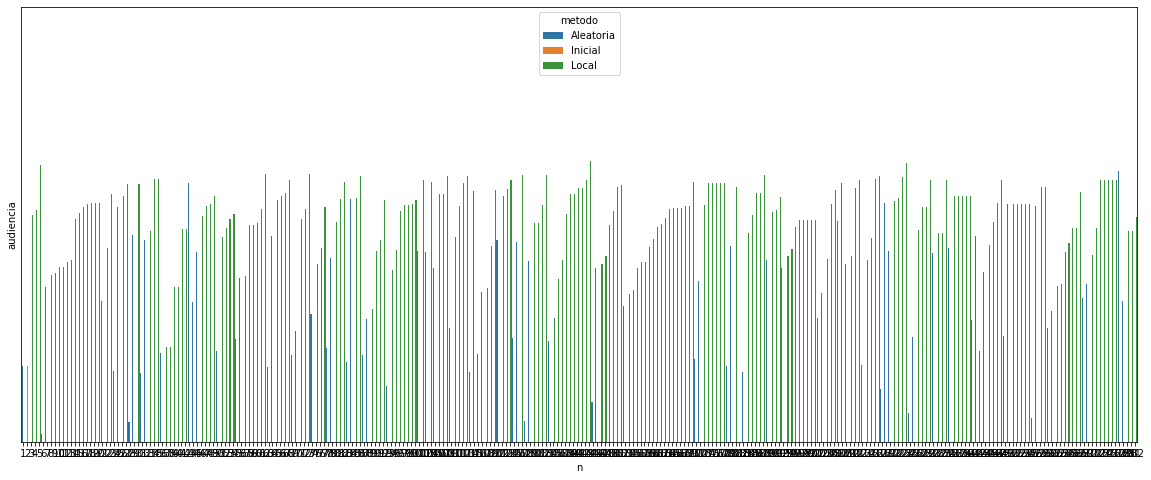

In [189]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)
ax.grid()
sns.barplot(data = resultados,
             x ='n',
             y ='audiencia',
             hue='metodo'
            )
ax.set(ylim=(6, 8))

In [190]:
#Verificacmos que el mejor resultado devuelto, haya sido el mejor de la lista de todos los resultados.
print(max(resultados['audiencia']))

7.223


**Conclusiones:**

1. Para este ejemplo el algoritmo supéra la audiencia del algoritmo voraz, la cual nos dio también como resultado: 7.2229 M de audiencia.

2. Se generaron y aceptaron soluciones de menor audiencia con la intención de salir de máximos locales.

3. En la gráfica podemos ver cómo la busqueda local, máximiza la audiencia.

In [191]:
#Verificamos si existen opciones con partidos simultaneos que generen una mejor audiencia.

print('Audiencia Inicial: ' + str(sum(our_best_scheduler_ene['total'])))
simu_schedule, resultados = match_simultaneity(our_best_scheduler_ene)
print('Audiencia Local: ' + str(sum(simu_schedule['total'])))
display(simu_schedule)

Audiencia Inicial: 7.223
Audiencia Local: 7.223


,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,D16,0.75,0.6750,1,0.6750
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,S12,0.55,0.4125,1,0.4125
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D20,1.00,1.3000,1,1.3000
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,L20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,V20,0.40,0.3000,1,0.3000
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,D18,0.85,0.7650,1,0.7650
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D12,0.45,0.3375,1,0.3375
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,S16,0.70,0.5250,1,0.5250
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200


# Calcula la complejidad del algoritmo 

Respuesta: Al ser un algoritmo metaheuristico, el orden de complejidad es complejo de cálcular, pero podemos establecer que este se encuentra en el orden de sus componentes o submodulos utilizados.

Orden de complejidad **algoritmo voraz** = O(n) = 2n*log(n) 
- (debido a las ordenación interna, ya que se ordenan las dos listas)

Orden de complejidad **busqueda local** = 0(n**2)
- Se intercambian los encuentros tratando de encontrar una mejor solución en el vecindario.

orden de complejidad **Orquestador** = 2nlog(n) + 5(n**2)

- 5 corresponde a la cantidad de iteraciones de busqueda local
 
por ende podemos decir que el orden de complejidad de nuestro algoritmo orquestador está entre un orden de O(n)=(n**2) lo cual nos da un orden cuadratico.


Si usamos solo la solución Voraz el orden sería: nLog(n), la cual es una solución rápida y que da buenos resultados. 



# Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

Respuesta, en el apartado incial se generó la un algoritmos para generación de paridos aleatorios. A continuación vamos a hacer el llamado del método, en varios acasiones para que nos genere la lista de encuentros y generaremos la solució propuesta por el algoritmo para ambos casos.

In [133]:
journey3= generate_maths(teamCategory)
#Presentamos la jornada inicial
print(journey3)

                    match category  base_m
0     (Valencia, Osasuna)   (B, C)    0.75
1    (R. Sociedad, Eibar)   (B, C)    0.75
2      (Getafe, Mallorca)   (B, C)    0.75
3  (Real Madrid, Leganes)   (A, C)    1.00
4     (Levante, Atletico)   (B, A)    1.30
5     (Athletic, Sevilla)   (B, B)    0.90
6     (Alaves, Villareal)   (B, B)    0.90
7          (Betis, Celta)   (B, B)    0.90
8   (Valladolid, Español)   (C, B)    0.75
9    (Granada, Barcelona)   (C, A)    1.00


# Aplica el algoritmo al juego de datos generado

Vamos a hacer dos ejemplos, uno utilizando la busqueda aleatoria como primera solución y el otro utilizando el algoritmo voraz como primera solución.

In [134]:
#Aplicamo el algoritmo mediante busqueda aleatoria

schedulerVoraz = generate_schedule_voraz(journey3,schedulePon)

#generamos la solución para la jornada, con aleatoriedad
schedulerJourney3, r3 = simulated_annealing(journey3, schedulePon, T, alpha, aleatory=True)

#audiencia 
audiencia3=sum(schedulerJourney3['total'])
print(f'Resultado mejor audiencia potencial: {audiencia3} y el número de iteraciones total fue: {r3.shape[0]}')

#Configuraión de la jornada
display(schedulerJourney3)


Audiencia inicial del Problema: 6.2975
Resultado mejor audiencia potencial: 6.5200000000000005 y el número de iteraciones total fue: 261


,match,category,base_m,id_match,schedule,ponde,base_ponde,concidence,total
0,"(Valencia, Osasuna)","(B, C)",0.75,0,S12,0.55,0.4125,1,0.4125
1,"(R. Sociedad, Eibar)","(B, C)",0.75,1,V20,0.40,0.3000,1,0.3000
2,"(Getafe, Mallorca)","(B, C)",0.75,2,D12,0.45,0.3375,1,0.3375
3,"(Real Madrid, Leganes)","(A, C)",1.00,3,S18,0.80,0.8000,1,0.8000
4,"(Levante, Atletico)","(B, A)",1.30,4,S20,1.00,1.3000,1,1.3000
5,"(Athletic, Sevilla)","(B, B)",0.90,5,D18,0.85,0.7650,1,0.7650
6,"(Alaves, Villareal)","(B, B)",0.90,6,S16,0.70,0.6300,1,0.6300
7,"(Betis, Celta)","(B, B)",0.90,7,D16,0.75,0.6750,1,0.6750
8,"(Valladolid, Español)","(C, B)",0.75,8,L20,0.40,0.3000,1,0.3000
9,"(Granada, Barcelona)","(C, A)",1.00,9,D20,1.00,1.0000,1,1.0000


Graficamos el avance de las soluciones encontradas

[(5.0, 8.0)]

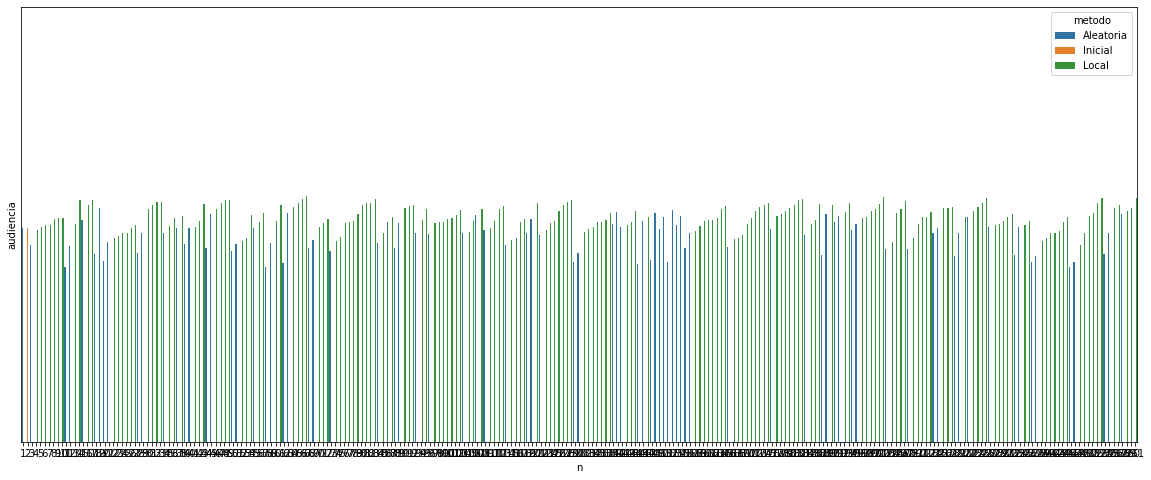

In [135]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)
ax.grid()
sns.barplot(data = r3,
             x ='n',
             y ='audiencia',
             hue='metodo'
            )
ax.set(ylim=(5, 8))

In [192]:
##Generamos la misma solución partiendo del algoritmo voraz

schedulerVoraz = generate_schedule_voraz(journey3,schedulePon)

#generamos la solución para la jornada, con aleatoriedad
schedulerJourney3, r3 = simulated_annealing(journey3, schedulePon, T, alpha, aleatory=False)

#audiencia 
audiencia3=sum(schedulerJourney3['total'])
print(f'Resultado mejor audiencia potencial: {audiencia3} y el número de iteraciones total fue: {r3.shape[0]}')

#Configuraión de la jornada
display(schedulerJourney3)

Audiencia inicial del Problema: 6.524999999999999
Resultado mejor audiencia potencial: 6.525000000000001 y el número de iteraciones total fue: 857


,match,category,base_m,id_match,schedule,ponde,base_ponde,concidence,total
0,"(Valencia, Osasuna)","(B, C)",0.75,0,S12,0.55,0.4125,1,0.4125
1,"(R. Sociedad, Eibar)","(B, C)",0.75,1,L20,0.40,0.3000,1,0.3000
2,"(Getafe, Mallorca)","(B, C)",0.75,2,V20,0.40,0.3000,1,0.3000
3,"(Real Madrid, Leganes)","(A, C)",1.00,3,D18,0.85,0.8500,1,0.8500
4,"(Levante, Atletico)","(B, A)",1.30,4,D20,1.00,1.3000,1,1.3000
5,"(Athletic, Sevilla)","(B, B)",0.90,5,S18,0.80,0.7200,1,0.7200
6,"(Alaves, Villareal)","(B, B)",0.90,6,D16,0.75,0.6750,1,0.6750
7,"(Betis, Celta)","(B, B)",0.90,7,S16,0.70,0.6300,1,0.6300
8,"(Valladolid, Español)","(C, B)",0.75,8,D12,0.45,0.3375,1,0.3375
9,"(Granada, Barcelona)","(C, A)",1.00,9,S20,1.00,1.0000,1,1.0000


partiendo de la solución Voráz vemos una mejora, pero es muy breve y quisas pueda ser despreciable, teniendo en cuenta el tiempo de computo.

**Otro ejemplo**

In [193]:
journey4= generate_maths(teamCategory)
#Presentamos la jornada inicial
print(journey4)

                       match category  base_m
0        (Barcelona, Getafe)   (A, B)    1.30
1           (Betis, Levante)   (B, B)    0.90
2         (Sevilla, Osasuna)   (B, C)    0.75
3           (Granada, Eibar)   (C, C)    0.47
4       (Real Madrid, Celta)   (A, B)    1.30
5         (Alaves, Atletico)   (B, A)    1.30
6        (Valencia, Leganes)   (B, C)    0.75
7      (Villareal, Mallorca)   (B, C)    0.75
8  (Valladolid, R. Sociedad)   (C, B)    0.75
9        (Español, Athletic)   (B, B)    0.90


In [194]:
#generamos la solución para la jornada, partiendo desde la técnica voraz.
schedulerJourney4, r4 = simulated_annealing(journey4, schedulePon, T, alpha, aleatory=False)

#audiencia 
audiencia4=sum(schedulerJourney4['total'])
print(f'Resultado mejor audiencia potencial: {audiencia4} y el número de iteraciones total fue: {r4.shape[0]}')

#Configuraión de la jornada
display(schedulerJourney4)

Audiencia inicial del Problema: 6.8629999999999995
Resultado mejor audiencia potencial: 6.8629999999999995 y el número de iteraciones total fue: 317


,match,category,base_m,schedule,ponde,id_match,base_ponde,concidence,total
0,"(Barcelona, Getafe)","(A, B)",1.30,S20,1.00,0,1.3000,1,1.3000
1,"(Betis, Levante)","(B, B)",0.90,S18,0.80,1,0.7200,1,0.7200
2,"(Sevilla, Osasuna)","(B, C)",0.75,S16,0.70,2,0.5250,1,0.5250
3,"(Granada, Eibar)","(C, C)",0.47,L20,0.40,3,0.1880,1,0.1880
4,"(Real Madrid, Celta)","(A, B)",1.30,D20,1.00,4,1.3000,1,1.3000
5,"(Alaves, Atletico)","(B, A)",1.30,D18,0.85,5,1.1050,1,1.1050
6,"(Valencia, Leganes)","(B, C)",0.75,S12,0.55,6,0.4125,1,0.4125
7,"(Villareal, Mallorca)","(B, C)",0.75,D12,0.45,7,0.3375,1,0.3375
8,"(Valladolid, R. Sociedad)","(C, B)",0.75,V20,0.40,8,0.3000,1,0.3000
9,"(Español, Athletic)","(B, B)",0.90,D16,0.75,9,0.6750,1,0.6750


Graficamos el avance de las soluciones encontradas

[(5.0, 8.0)]

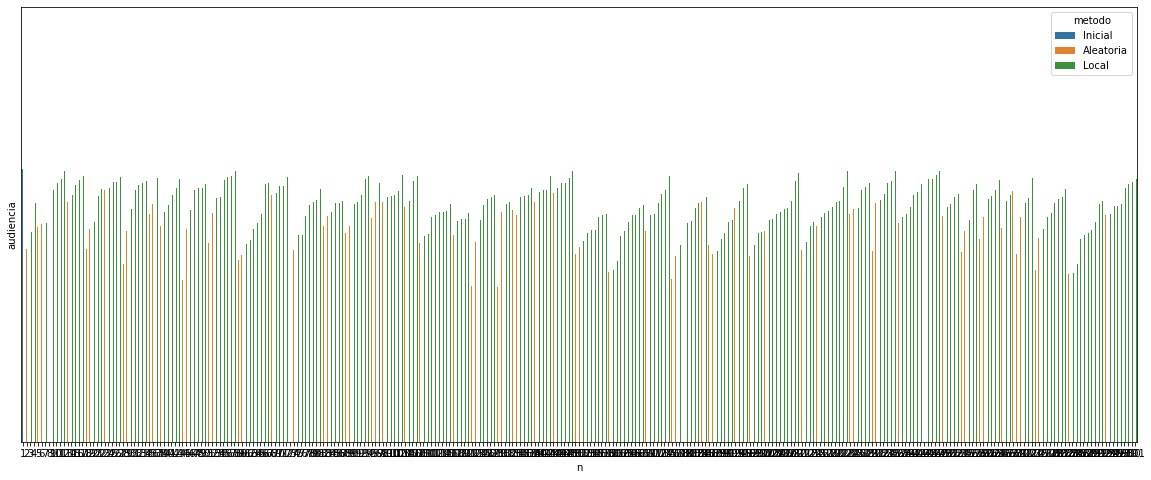

In [184]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)
ax.grid()
sns.barplot(data = r4,
             x ='n',
             y ='audiencia',
             hue='metodo'
            )
ax.set(ylim=(5, 8))

In [195]:
#Verificacmos que el mejor resultado devuelto, haya sido el mejor de la lista de todos los resultados.
print(max(r4['audiencia']))

6.8629999999999995


In [196]:
#Verificamos si existen opciones con partidos simultaneos que generen una mejor audiencia.

print('Audiencia Inicial: ' + str(sum(schedulerJourney4['total'])))
simu_schedule, resultados = match_simultaneity(schedulerJourney4)
print('Audiencia Local: ' + str(sum(simu_schedule['total'])))
display(simu_schedule)

Audiencia Inicial: 6.8629999999999995
Audiencia Local: 6.8629999999999995


,match,category,base_m,schedule,ponde,id_match,base_ponde,concidence,total
0,"(Barcelona, Getafe)","(A, B)",1.30,S20,1.00,0,1.3000,1,1.3000
1,"(Betis, Levante)","(B, B)",0.90,S18,0.80,1,0.7200,1,0.7200
2,"(Sevilla, Osasuna)","(B, C)",0.75,S16,0.70,2,0.5250,1,0.5250
3,"(Granada, Eibar)","(C, C)",0.47,L20,0.40,3,0.1880,1,0.1880
4,"(Real Madrid, Celta)","(A, B)",1.30,D20,1.00,4,1.3000,1,1.3000
5,"(Alaves, Atletico)","(B, A)",1.30,D18,0.85,5,1.1050,1,1.1050
6,"(Valencia, Leganes)","(B, C)",0.75,S12,0.55,6,0.4125,1,0.4125
7,"(Villareal, Mallorca)","(B, C)",0.75,D12,0.45,7,0.3375,1,0.3375
8,"(Valladolid, R. Sociedad)","(C, B)",0.75,V20,0.40,8,0.3000,1,0.3000
9,"(Español, Athletic)","(B, B)",0.90,D16,0.75,9,0.6750,1,0.6750


Para este caso tampoco se nota mejoría, cuando tratamos de generar partidos en simultaneo.

# Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

* Actividad guiada #3.
* Manual de la asignatura algoritmos de optimización.

 **Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño**

Respuesta:



*   Un algoritmo GRASP: Aprovechando la solución inicial voraz y definiendola como primera solución factible, a partir de la cual se generaran soluciones vecinas en una lista restringida de candidatos por medio de busqueda local. Luego de esto se hace la selección aleatoria y ponderada de una de las soluciones vecinas, con el fin de seguir iterando y buscando nuevas soluciones. 

*   Otra opción de mejora son lo algoritmos geneticos, en el cual se combinen partes de varias soluciones(padra y madre) y luego de esto continuar con busqueda local para optimizar los hijos generados.